#**Machine Learning-Based Revenue Forecasting** and Onboarding Patterns Across Multi-Country Payment Networks: **A Case Study of Arab Financial Services**

#**Egypt AFS (Arab Financial Services) Forcast Revenue**

#SECTION 1 — Setup: Google Drive + Libraries

In [30]:
# --- Mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

# --- Core libraries ---
import pandas as pd
import numpy as np

# --- Feature Engineering ---
!pip install holidays -q
import holidays
!pip install hijridate -q
from hijridate import Gregorian

# --- Visualisation ---
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# --- Modelling ---
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
import xgboost as xgb
!pip install lightgbm catboost pmdarima -q
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# --- Display settings ---
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style('whitegrid')

# --- File path ---
FILE_PATH = '/content/drive/MyDrive/Colab Notebooks/Thesis/Thesis_Datasets/EG_AFS_daily_revenue_dataset_v3.xlsx'

print('Setup complete.')
print('Libraries loaded: pandas, numpy, matplotlib, seaborn, sklearn, xgboost')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete.
Libraries loaded: pandas, numpy, matplotlib, seaborn, sklearn, xgboost


#SECTION 2 — Data Structure

In [31]:
df_raw = pd.read_excel(FILE_PATH)
df_raw['Settlement Date'] = pd.to_datetime(df_raw['Settlement Date'])

# ---------- 2.1 Structure ----------
print('=' * 70)
print('2.1  DATA STRUCTURE')
print('=' * 70)
print(f'Shape       : {df_raw.shape[0]:,} rows  x  {df_raw.shape[1]} columns')
print(f'Date range  : {df_raw["Settlement Date"].min().date()}  ->  {df_raw["Settlement Date"].max().date()}')
print(f'Memory      : {df_raw.memory_usage(deep=True).sum()/1024:.1f} KB')
print()
print(df_raw.dtypes.to_frame('dtype').to_string())
print()
display(df_raw.head())

# ---------- 2.2 Data quality: nulls, duplicates, zeros ----------
print('=' * 70)
print('2.2  DATA QUALITY')
print('=' * 70)

quality = pd.DataFrame({
    'dtype'  : df_raw.dtypes.astype(str),
    'nulls'  : df_raw.isna().sum(),
    'null_%' : (df_raw.isna().sum() / len(df_raw) * 100).round(2),
    'zeros'  : (df_raw == 0).sum(),
    'unique' : df_raw.nunique(),
})
display(quality)

print(f'Duplicate full rows       : {df_raw.duplicated().sum()}')
print(f'Duplicate Settlement Dates: {df_raw["Settlement Date"].duplicated().sum()}')

full_range   = pd.date_range(df_raw['Settlement Date'].min(),
                             df_raw['Settlement Date'].max(), freq='D')
missing_days = full_range.difference(df_raw['Settlement Date'])
print(f'Missing calendar days     : {len(missing_days)}')
if 0 < len(missing_days) <= 10:
    print(f'   -> {list(missing_days.date)}')
print()

# ---------- 2.3 Statistical summary ----------
print('=' * 70)
print('2.3  STATISTICAL SUMMARY')
print('=' * 70)
num_cols = ['Transaction Count', 'Transaction Amount',
            'Average Transaction Amount', 'Profit']
stats = df_raw[num_cols].describe().T
stats['skew'] = df_raw[num_cols].skew()
display(stats.round(2))

# ---------- 2.4 Yearly consistency (margin check) ----------
print('=' * 70)
print('2.4  YEARLY BREAKDOWN — margin consistency check')
print('=' * 70)
yr = df_raw.groupby(df_raw['Settlement Date'].dt.year).agg(
    days             = ('Profit', 'size'),
    txn_count        = ('Transaction Count', 'sum'),
    amount           = ('Transaction Amount', 'sum'),
    profit           = ('Profit', 'sum'),
    avg_daily_profit = ('Profit', 'mean'),
)
yr['margin_%'] = (yr['profit'] / yr['amount'] * 100).round(2)
display(yr.round(0))

2.1  DATA STRUCTURE
Shape       : 1,256 rows  x  15 columns
Date range  : 2023-01-01  ->  2026-07-05
Memory      : 314.1 KB

                                     dtype
Country                             object
Source                              object
Currency                            object
Transaction Count                    int64
Transaction Amount                 float64
Average Transaction Amount         float64
Profit                             float64
Settlement Year                      int64
Settlement Month                     int64
Settlement Date             datetime64[ns]
Settlement Day                       int64
is_weekend                           int64
is_holiday                           int64
is_ramadan                           int64
ramadan_last10                       int64



,Country,Source,Currency,Transaction Count,Transaction Amount,Average Transaction Amount,Profit,Settlement Year,Settlement Month,Settlement Date,Settlement Day,is_weekend,is_holiday,is_ramadan,ramadan_last10
0,Egypt,CMMEG,EGP,7589,"1,176,295,000.00","155,000.00","24,584,565.50",2023,1,2023-01-01,6,0,0,0,0
1,Egypt,CMMEG,EGP,7743,"1,199,415,013.02","154,903.14","24,834,024.68",2023,1,2023-01-02,0,0,0,0,0
2,Egypt,CMMEG,EGP,7550,"1,153,773,635.00","152,817.70","24,125,400.97",2023,1,2023-01-03,1,0,0,0,0
3,Egypt,CMMEG,EGP,7488,"1,144,468,241.28","152,840.31","23,755,884.70",2023,1,2023-01-04,2,0,0,0,0
4,Egypt,CMMEG,EGP,6261,"970,079,465.22","154,940.02","19,884,168.16",2023,1,2023-01-05,3,0,0,0,0


2.2  DATA QUALITY


,dtype,nulls,null_%,zeros,unique
Country,object,0,0.00,0,1
Source,object,0,0.00,0,1
Currency,object,0,0.00,0,1
Transaction Count,int64,0,0.00,0,1155
Transaction Amount,float64,0,0.00,0,1256
Average Transaction Amount,float64,0,0.00,0,1256
Profit,float64,0,0.00,0,1256
Settlement Year,int64,0,0.00,0,4
Settlement Month,int64,0,0.00,0,12
Settlement Date,datetime64[ns],0,0.00,0,1256


Duplicate full rows       : 0
Duplicate Settlement Dates: 0
Missing calendar days     : 26

2.3  STATISTICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max,skew
Transaction Count,"1,256.00","8,705.17","2,052.43","4,940.00","7,118.75","8,449.00","10,110.75","17,842.00",0.66
Transaction Amount,"1,256.00","1,532,640,395.14","447,170,347.99","766,900,876.75","1,181,870,487.56","1,468,668,075.84","1,829,260,065.15","3,508,003,759.48",0.70
Average Transaction Amount,"1,256.00","173,924.50","11,302.89","152,349.66","164,254.13","173,668.66","183,547.91","199,201.94",0.09
Profit,"1,256.00","31,960,608.37","10,289,301.88","13,272,860.28","23,999,297.22","30,345,280.54","38,203,297.92","87,265,956.11",1.03


2.4  YEARLY BREAKDOWN — margin consistency check


,days,txn_count,amount,profit,avg_daily_profit,margin_%
Settlement Date,,,,,,
2023,351,2383025,"382,168,705,796.00","7,889,447,516.00","22,477,058.00",2.00
2024,363,2954842,"504,985,450,905.00","10,503,393,621.00","28,934,969.00",2.00
2025,360,3523750,"642,029,607,575.00","13,437,092,363.00","37,325,257.00",2.00
2026,182,2072074,"395,812,572,024.00","8,312,590,616.00","45,673,575.00",2.00


#SECTION 3 — Cleaning

In [32]:
df = df_raw.copy()
df.columns = df.columns.str.strip()

# ---------- 3.1 Drop constant metadata columns ----------
df = df.drop(columns=['Country', 'Source', 'Currency'], errors='ignore')

# ---------- 3.2 Resolve duplicate dates (sum the additive metrics) ----------
n_dups = df['Settlement Date'].duplicated().sum()
df = (df.groupby('Settlement Date', as_index=False)
        .agg({'Transaction Count' : 'sum',
              'Transaction Amount': 'sum',
              'Profit'            : 'sum'}))

# ---------- 3.3 Fill missing calendar days with that MONTH's average ----------
df = df.sort_values('Settlement Date').reset_index(drop=True)

full_range   = pd.date_range(df['Settlement Date'].min(),
                             df['Settlement Date'].max(), freq='D')
missing_days = full_range.difference(df['Settlement Date'])

if len(missing_days) > 0:
    df['_ym']  = df['Settlement Date'].dt.to_period('M')
    month_avg  = df.groupby('_ym')[['Transaction Count',
                                    'Transaction Amount',
                                    'Profit']].mean()

    fills = []
    for d in missing_days:
        ym   = pd.Period(d, freq='M')
        vals = month_avg.loc[ym] if ym in month_avg.index else \
               df[['Transaction Count','Transaction Amount','Profit']].mean()
        fills.append({'Settlement Date'   : d,
                      'Transaction Count' : vals['Transaction Count'],
                      'Transaction Amount': vals['Transaction Amount'],
                      'Profit'            : vals['Profit']})

    df = df.drop(columns='_ym')
    df = pd.concat([df, pd.DataFrame(fills)], ignore_index=True)
    df = df.sort_values('Settlement Date').reset_index(drop=True)

# ---------- 3.4 Recompute Average Transaction Amount ----------
df['Average Transaction Amount'] = (
    df['Transaction Amount'] / df['Transaction Count']
).replace([np.inf, -np.inf], np.nan)

# ---------- 3.5 Rebuild calendar columns ----------
df['Settlement Year']  = df['Settlement Date'].dt.year
df['Settlement Month'] = df['Settlement Date'].dt.month
df['Settlement Day']   = df['Settlement Date'].dt.dayofweek   # 0=Mon ... 6=Sun

# ---------- 3.6 Verification ----------
final_range   = pd.date_range(df['Settlement Date'].min(),
                              df['Settlement Date'].max(), freq='D')
still_missing = final_range.difference(df['Settlement Date'])

print('=' * 70)
print('CLEANING VERIFICATION')
print('=' * 70)
print(f'Rows            : {len(df_raw):,}  ->  {len(df):,}')
print(f'Duplicate dates : {n_dups}  ->  {df["Settlement Date"].duplicated().sum()}')
print(f'Missing days    : {len(missing_days)}  ->  {len(still_missing)} ')
if len(missing_days):
    print(f'   filled       : {list(missing_days.date)}')
print(f'Profit zeros    : {(df["Profit"] == 0).sum()}')
print(f'Nulls remaining : {df.isna().sum().sum()}')
print()
print(f'Avg Txn Amount  : min {df["Average Transaction Amount"].min():.2f}  '
      f'max {df["Average Transaction Amount"].max():.2f}  '
      f'median {df["Average Transaction Amount"].median():.2f}')
print(f'Columns: {list(df.columns)}')
display(df.head())

CLEANING VERIFICATION
Rows            : 1,256  ->  1,282
Duplicate dates : 0  ->  0
Missing days    : 26  ->  0 
   filled       : [datetime.date(2023, 4, 12), datetime.date(2023, 4, 14), datetime.date(2023, 4, 15), datetime.date(2023, 4, 21), datetime.date(2023, 5, 13), datetime.date(2023, 5, 27), datetime.date(2023, 6, 3), datetime.date(2023, 6, 17), datetime.date(2023, 6, 23), datetime.date(2023, 7, 28), datetime.date(2023, 8, 30), datetime.date(2023, 9, 24), datetime.date(2023, 10, 27), datetime.date(2023, 11, 3), datetime.date(2024, 8, 14), datetime.date(2024, 12, 13), datetime.date(2024, 12, 31), datetime.date(2025, 5, 21), datetime.date(2025, 6, 20), datetime.date(2025, 6, 23), datetime.date(2025, 9, 10), datetime.date(2025, 11, 14), datetime.date(2026, 3, 26), datetime.date(2026, 5, 19), datetime.date(2026, 6, 24), datetime.date(2026, 7, 3)]
Profit zeros    : 0
Nulls remaining : 0

Avg Txn Amount  : min 152349.66  max 199201.94  median 173618.61
Columns: ['Settlement Date', 'Tr

,Settlement Date,Transaction Count,Transaction Amount,Profit,Average Transaction Amount,Settlement Year,Settlement Month,Settlement Day
0,2023-01-01,"7,589.00","1,176,295,000.00","24,584,565.50","155,000.00",2023,1,6
1,2023-01-02,"7,743.00","1,199,415,013.02","24,834,024.68","154,903.14",2023,1,0
2,2023-01-03,"7,550.00","1,153,773,635.00","24,125,400.97","152,817.70",2023,1,1
3,2023-01-04,"7,488.00","1,144,468,241.28","23,755,884.70","152,840.31",2023,1,2
4,2023-01-05,"6,261.00","970,079,465.22","19,884,168.16","154,940.02",2023,1,3


#SECTION 5 — Feature Engineering

In [33]:
# ---------- 5.1 is_weekend (Egypt: Friday=4, Saturday=5) ----------
df['is_weekend'] = df['Settlement Date'].dt.dayofweek.isin([4, 5]).astype(int)

# ---------- 5.2 is_holiday (Egypt public holidays) ----------
eg_holidays = holidays.Egypt(years=[2023, 2024, 2025, 2026])
df['is_holiday'] = df['Settlement Date'].dt.date.isin(eg_holidays).astype(int)
print(f'Holiday days flagged: {df["is_holiday"].sum()}')

# ---------- 5.3 Lag & rolling features ----------
df['lag_1']           = df['Profit'].shift(1)                        # yesterday's profit
df['avg_tran_lag1'] = df['Average Transaction Amount'].shift(1)    # yesterday's avg ticket size
df['roll7_mean']      = df['Profit'].rolling(7).mean().shift(1)      # last 7-day avg profit
df['lag_28']          = df['Profit'].shift(28)                       # four weeks back (monthly cycle)

# ---------- 5.4 Islamic-calendar (Hijri) features ----------
# Ramadan spending drops ~26.5%; it shifts ~11 days earlier each Gregorian year,
# so Settlement Month cannot capture it — a Hijri flag is required.
def _hijri(dt):
    h = Gregorian(dt.year, dt.month, dt.day).to_hijri()
    return pd.Series({'hijri_month': h.month, 'hijri_day': h.day})

_h = df['Settlement Date'].apply(_hijri)
df['hijri_month'] = _h['hijri_month']
df['hijri_day']   = _h['hijri_day']

df['is_ramadan']     = (df['hijri_month'] == 9).astype(int)                        # month 9 = Ramadan
df['ramadan_last10'] = ((df['hijri_month'] == 9) & (df['hijri_day'] >= 20)).astype(int)  # pre-Eid peak

print(f'Ramadan days flagged   : {df["is_ramadan"].sum()}')

# drop the raw hijri_month/day — they HURT as ordinal features (cyclical); keep only the flags
df = df.drop(columns=['hijri_month', 'hijri_day'])

# ---------- 5.5 FINAL DATASET ----------
print('=' * 70)
print('FINAL DATASET')
print('=' * 70)
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
print()
print('--- First 10 rows ---')
display(df.head(10))

# ---------- 5.6 Ramadan effect check (nice for the thesis) ----------
print('\nRamadan effect on profit:')
r = df[df['is_ramadan']==1]['Profit'].mean()
n = df[df['is_ramadan']==0]['Profit'].mean()
print(f'  Ramadan    : {r:,.0f} EGP/day')
print(f'  Non-Ramadan: {n:,.0f} EGP/day')
print(f'  Effect     : {(r/n-1)*100:+.1f}%')

Holiday days flagged: 63
Ramadan days flagged   : 118
FINAL DATASET
Shape: 1,282 rows x 16 columns
Columns: ['Settlement Date', 'Transaction Count', 'Transaction Amount', 'Profit', 'Average Transaction Amount', 'Settlement Year', 'Settlement Month', 'Settlement Day', 'is_weekend', 'is_holiday', 'lag_1', 'avg_tran_lag1', 'roll7_mean', 'lag_28', 'is_ramadan', 'ramadan_last10']

--- First 10 rows ---


,Settlement Date,Transaction Count,Transaction Amount,Profit,Average Transaction Amount,Settlement Year,Settlement Month,Settlement Day,is_weekend,is_holiday,lag_1,avg_tran_lag1,roll7_mean,lag_28,is_ramadan,ramadan_last10
0,2023-01-01,"7,589.00","1,176,295,000.00","24,584,565.50","155,000.00",2023,1,6,0,0,NaN,NaN,NaN,NaN,0,0
1,2023-01-02,"7,743.00","1,199,415,013.02","24,834,024.68","154,903.14",2023,1,0,0,0,"24,584,565.50","155,000.00",NaN,NaN,0,0
2,2023-01-03,"7,550.00","1,153,773,635.00","24,125,400.97","152,817.70",2023,1,1,0,0,"24,834,024.68","154,903.14",NaN,NaN,0,0
3,2023-01-04,"7,488.00","1,144,468,241.28","23,755,884.70","152,840.31",2023,1,2,0,0,"24,125,400.97","152,817.70",NaN,NaN,0,0
4,2023-01-05,"6,261.00","970,079,465.22","19,884,168.16","154,940.02",2023,1,3,0,0,"23,755,884.70","152,840.31",NaN,NaN,0,0
5,2023-01-06,"5,072.00","785,755,305.12","15,939,749.00","154,920.21",2023,1,4,1,0,"19,884,168.16","154,940.02",NaN,NaN,0,0
6,2023-01-07,"4,950.00","776,323,399.50","15,915,996.04","156,833.01",2023,1,5,1,0,"15,939,749.00","154,920.21",NaN,NaN,0,0
7,2023-01-08,"6,275.00","973,232,043.50","19,636,312.96","155,096.74",2023,1,6,0,1,"15,915,996.04","156,833.01","21,291,398.44",NaN,0,0
8,2023-01-09,"6,373.00","996,104,616.02","20,252,210.84","156,300.74",2023,1,0,0,0,"19,636,312.96","155,096.74","20,584,505.22",NaN,0,0
9,2023-01-10,"6,398.00","994,197,824.06","20,339,110.44","155,391.97",2023,1,1,0,0,"20,252,210.84","156,300.74","19,929,960.38",NaN,0,0



Ramadan effect on profit:
  Ramadan    : 31,414,795 EGP/day
  Non-Ramadan: 32,001,743 EGP/day
  Effect     : -1.8%


#SECTION 7: Model Training & Evaluation

In [34]:
FEATURES = ['Settlement Year', 'Settlement Month', 'Settlement Day',
            'is_weekend', 'is_holiday',
            'lag_1','avg_tran_lag1','roll7_mean', 'lag_28','is_ramadan', 'ramadan_last10']
TARGET = 'Profit'
SPLIT  = '2026-03-01'

def evaluate(y, p):
    ape = np.abs((y - p) / y) * 100
    return {'MAPE%' : ape.mean(),
            'MAE'   : mean_absolute_error(y, p),
            'RMSE'  : np.sqrt(mean_squared_error(y, p))#,
            #'R2'    : r2_score(y, p)
        }
# ---------- split (once — FEATURES is a single list) ----------
d  = df.dropna(subset=FEATURES + [TARGET]).copy()
tr = d[d['Settlement Date'] <  SPLIT]
te = d[d['Settlement Date'] >= SPLIT]

X_tr, y_tr = tr[FEATURES], tr[TARGET]
X_te, y_te = te[FEATURES], te[TARGET]

print(f'TRAIN: {len(tr):,} rows | {tr["Settlement Date"].min().date()} -> {tr["Settlement Date"].max().date()}')
print(f'TEST : {len(te):,} rows | {te["Settlement Date"].min().date()} -> {te["Settlement Date"].max().date()}')
print()

# ---------- BASELINE ----------
baselines = {
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
}

# ---------- PROPOSED MODELS ----------
models = {
    'Random Forest'     : RandomForestRegressor(n_estimators=1000,
                                                random_state=42, n_jobs=-1),

    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=1000, learning_rate=0.01,
                                                    max_depth=6, subsample=0.8,
                                                    random_state=42),

    'XGBoost'           : xgb.XGBRegressor(n_estimators=1000, learning_rate=0.01,
                                           max_depth=6, random_state=42, n_jobs=-1),

}

rows = []

for mname, model in baselines.items():
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    rows.append({'Type': 'Baseline', 'Model': mname, **evaluate(y_te.values, pred)})

for mname, model in models.items():
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    rows.append({'Type': 'Proposed', 'Model': mname, **evaluate(y_te.values, pred)})

results = pd.DataFrame(rows)

print('Egypt AFS MODEL COMPARISON (2026 test set)')
display(results.round(2))

TRAIN: 1,127 rows | 2023-01-29 -> 2026-02-28
TEST : 127 rows | 2026-03-01 -> 2026-07-05

Egypt AFS MODEL COMPARISON (2026 test set)


,Type,Model,MAPE%,MAE,RMSE
0,Baseline,Decision Tree,12.92,"6,762,820.25","9,725,697.00"
1,Proposed,Random Forest,8.98,"5,102,494.84","8,950,675.53"
2,Proposed,Gradient Boosting,9.81,"5,502,678.16","9,072,127.65"
3,Proposed,XGBoost,10.69,"5,890,903.43","9,281,768.84"


#Check Overfitting/Underfitting

In [35]:
def mape(y, p):
    return np.mean(np.abs((y - p) / y)) * 100

# ---- collect train vs test scores for each model ----
names, tr_mape, te_mape, tr_rmse, te_rmse = [], [], [], [], []

for mname, model in {**baselines, **models}.items():
    model.fit(X_tr, y_tr)
    names.append(mname)
    tr_mape.append(mape(y_tr.values, model.predict(X_tr)))
    te_mape.append(mape(y_te.values, model.predict(X_te)))
    tr_rmse.append(np.sqrt(mean_squared_error(y_tr, model.predict(X_tr))))
    te_rmse.append(np.sqrt(mean_squared_error(y_te, model.predict(X_te))))

# ---- print the gap table ----
print(f'{"Model":<20}{"Train MAPE":>11}{"Test MAPE":>11}{"Gap":>8}')
print('-' * 50)
for i in range(len(names)):
    print(f'{names[i]:<20}{tr_mape[i]:>10.2f}%{te_mape[i]:>10.2f}%{te_mape[i]-tr_mape[i]:>7.1f}')

Model                Train MAPE  Test MAPE     Gap
--------------------------------------------------
Decision Tree             2.70%     12.92%   10.2
Random Forest             2.47%      8.98%    6.5
Gradient Boosting         1.93%      9.81%    7.9
XGBoost                   2.14%     10.69%    8.5


#SECTION 7: Prediction (Remaining of 2026)

In [40]:
# ============================================================
# RECURSIVE FORECAST — from end of data to 31 Dec 2026
# ============================================================
FEATURES = ['Settlement Year','Settlement Month','Settlement Day',
            'is_weekend','is_holiday',
            'lag_1','avg_tran_lag1','roll7_mean','lag_28',
            'is_ramadan','ramadan_last10']

EG = holidays.Egypt(years=[2023,2024,2025,2026])

def hijri_md(dt):
    h = Gregorian(dt.year, dt.month, dt.day).to_hijri()
    return h.month, h.day

last_date    = df['Settlement Date'].max()
future_dates = pd.date_range(last_date + pd.Timedelta(days=1), '2026-12-31', freq='D')

profit_hist = list(df['Profit'].values)
# yesterday's avg transaction amount — held at the recent 28-day average across the horizon
avg_tran    = df['Average Transaction Amount'].tail(28).mean()

future_rows = []
for dt in future_dates:
    hm, hd = hijri_md(dt)
    feat = {
        'Settlement Year' : dt.year,
        'Settlement Month': dt.month,
        'Settlement Day'  : dt.dayofweek,
        'is_weekend'      : int(dt.dayofweek in [4, 5]),
        'is_holiday'      : int(dt.date() in EG),
        'lag_1'           : profit_hist[-1],
        'avg_tran_lag1'   : avg_tran,              # ← matches your column name
        'roll7_mean'      : np.mean(profit_hist[-7:]),
        'lag_28'          : profit_hist[-28],
        'is_ramadan'      : int(hm == 9),
        'ramadan_last10'  : int(hm == 9 and hd >= 20),
    }
    yhat = float(model.predict(pd.DataFrame([feat])[FEATURES])[0])
    profit_hist.append(yhat)
    future_rows.append({'Settlement Date': dt, 'Predicted': yhat})

future = pd.DataFrame(future_rows)

print(f'Forecast: {future["Settlement Date"].min().date()} -> {future["Settlement Date"].max().date()}')
print(f'Days forecast     : {len(future)}')
print(f'Jul-Dec 2026 total: {future["Predicted"].sum():,.0f} EGP')
print(f'Daily mean        : {future["Predicted"].mean():,.0f} EGP')

# ---- combined table: actuals + forecast ----
actual = df[['Settlement Date','Profit']].rename(columns={'Profit':'Actual'})
actual['Predicted'] = np.nan
actual['Type']      = 'Actual'

fc = future.copy()
fc['Actual'] = np.nan
fc['Type']   = 'Forecast'

combined = pd.concat([actual[['Settlement Date','Actual','Predicted','Type']],
                      fc[['Settlement Date','Actual','Predicted','Type']]],
                     ignore_index=True).sort_values('Settlement Date').reset_index(drop=True)

combined['Profit_Best']       = combined['Actual'].fillna(combined['Predicted'])
combined['Cumulative Profit'] = combined.groupby(combined['Settlement Date'].dt.year)['Profit_Best'].cumsum()

combined.to_csv('EG_AFS_forecast_2026.csv', index=False)

Forecast: 2026-07-06 -> 2026-12-31
Days forecast     : 179
Jul-Dec 2026 total: 7,888,009,432 EGP
Daily mean        : 44,067,092 EGP


#Visualization

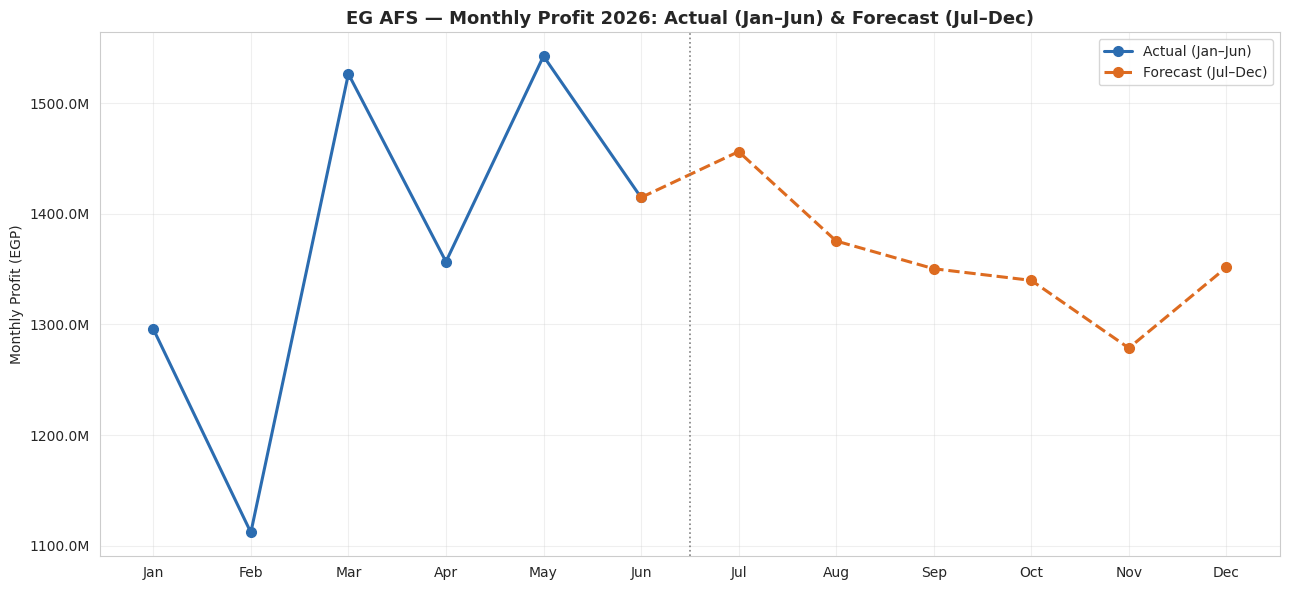

MONTHLY 2026 (EGP):
  Jan: 1,295,859,622  [Actual]
  Feb: 1,112,040,892  [Actual]
  Mar: 1,526,299,530  [Actual]
  Apr: 1,356,670,682  [Actual]
  May: 1,542,329,582  [Actual]
  Jun: 1,414,641,264  [Actual]
  Jul: 1,456,092,687  [Forecast]
  Aug: 1,375,336,266  [Forecast]
  Sep: 1,350,288,934  [Forecast]
  Oct: 1,339,758,034  [Forecast]
  Nov: 1,278,647,276  [Forecast]
  Dec: 1,351,500,970  [Forecast]

Total 2026: 16,399,465,740 EGP


In [41]:
# ---- combine 2026 daily actual + forecast, aggregate to MONTHLY ----
a = df[df['Settlement Date'].dt.year == 2026][['Settlement Date','Profit']].rename(columns={'Profit':'val'})
f = future.rename(columns={'Predicted':'val'})[['Settlement Date','val']]

alld = pd.concat([a, f], ignore_index=True).sort_values('Settlement Date')
alld['month'] = alld['Settlement Date'].dt.month
monthly = alld.groupby('month')['val'].sum()

names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
vals  = monthly.reindex(range(1,13)).values

# split: Jan-Jun actual, Jul-Dec forecast (overlap at Jun so the lines connect)
act_x, act_y = list(range(6)),   vals[:6]
fc_x,  fc_y  = list(range(5,12)), vals[5:]

plt.figure(figsize=(13,6))
plt.plot(act_x, act_y, 'o-',  color='#2B6CB0', lw=2.2, markersize=7, label='Actual (Jan–Jun)')
plt.plot(fc_x,  fc_y,  'o--', color='#DD6B20', lw=2.2, markersize=7, label='Forecast (Jul–Dec)')
plt.axvline(5.5, color='gray', ls=':', lw=1.2)

plt.xticks(range(12), names)
plt.ylabel('Monthly Profit (EGP)')
plt.title('EG AFS — Monthly Profit 2026: Actual (Jan–Jun) & Forecast (Jul–Dec)',
          weight='bold', fontsize=13)
plt.legend(); plt.grid(alpha=0.3)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

# ---- print the monthly table ----
print('MONTHLY 2026 (EGP):')
for i, v in enumerate(vals):
    kind = 'Actual' if i < 6 else 'Forecast'
    print(f'  {names[i]}: {v:>12,.0f}  [{kind}]')
print(f'\nTotal 2026: {vals.sum():,.0f} EGP')